In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from ugdatalab.utils.compose import Compose
from ugdatalab.models.galaxy_zoo import GalaxyZooGPUDataset
from ugdatalab.models.galaxy_zoo.constants import N_LABELS
from ugdatalab.methods.neural_network.cnn import train_cnn
from ugdatalab.methods.neural_network.augmentation_gpu import GpuCenterCrop

from architectures import build_custom_cnn
import plotters

/home/ikaros/projects/ay-128/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Custom CNN — Architecture Sweep (supporting Task 17)

This notebook is the empirical backing for the Custom-CNN architecture chosen in `04b-custom-cnn.ipynb` (Task 17). It is *not itself* one of the lab-manual deliverables — the lab manual only asks the student to describe and train a custom CNN and to comment on parameter count (Tasks 17–19) — but the depth and dropout choices in 04b are not arbitrary, and this short sweep is the defensible audit trail behind them.

The sweep is a one-variable-at-a-time grid around a central pivot (depth $\in \{3, 4, 5\}$, dropout $\in \{[0.1, 0.1],\ [0.25, 0.1],\ [0.25, 0.25]\}$ — three values on each axis with the pivot at the midpoint of both). Each variant is trained for `ABLATION_EPOCHS = 50` epochs and the full per-epoch curves + best-epoch weights are saved so any per-variant analysis can be done later without retraining. The "winning" variant by the readout below is the one trained for 100 epochs in `04b-custom-cnn.ipynb`.

The sweep runs *before* the long final training run because the cost of getting the architecture wrong and re-doing a 100-epoch baseline is much larger than the cost of training five 50-epoch variants up front.

In [2]:
# Load preprocessed data
img_data = np.load("artifacts/galaxy_zoo_images.npz")
images = img_data["images"]
label_data = np.load("artifacts/galaxy_zoo_labels.npz")
labels = label_data["labels"]
split_data = np.load("artifacts/split_indices.npz")
train_idx, val_idx = split_data["train_idx"], split_data["val_idx"]

train_images, val_images = images[train_idx], images[val_idx]
train_labels, val_labels = labels[train_idx], labels[val_idx]
INPUT_SIZE = 96
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 1024

default_transform = Compose([GpuCenterCrop(INPUT_SIZE)])
train_batches = GalaxyZooGPUDataset(
    train_images, train_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=True,
)
val_batches = GalaxyZooGPUDataset(
    val_images, val_labels, batch_size=BATCH_SIZE, transform=default_transform,
    device=DEVICE, shuffle=False,
)

### Architecture sweep

A one-variable-at-a-time sweep around a central pivot. For `ABLATION_EPOCHS` epochs each, we train five variants:

- **Pivot**: 4 conv blocks ($32 \to 64 \to 128 \to 256$), tapered FC dropout $[0.25, 0.1]$ (heavier on the parameter-dense first FC, lighter on the second).
- **Depth axis** at fixed tapered dropout $[0.25, 0.1]$: depth $\in \{3, 4, 5\}$.
- **Dropout axis** at fixed depth $4$: $\{[0.1, 0.1],\ [0.25, 0.1],\ [0.25, 0.25]\}$ — uniform-low, the mixed pivot, and uniform-high.

Both axes pass through the pivot at their midpoint, so each non-pivot variant tests exactly one variable. The dropout axis specifically tests whether the **tapered** $[0.25, 0.1]$ choice is better than either **uniform** value at the same average — i.e. whether weighting dropout toward the parameter-heavy FC1 actually pays off.

The factory `architectures.build_custom_cnn` handles shape bookkeeping automatically — manually tracking the post-pool spatial size through each depth variant would be painful.

Note on factory arguments when depth changes: `kernel_sizes` must have the same length as `n_channels_list` (the values can all stay $3$, only the list length matters); `fc_sizes` is independent of depth — the first `Linear` adapts to whatever flatten size comes out of the conv stack. `dropout_rate` accepts either a scalar (broadcast to every FC layer) or a length-2 list (per-layer).

Each variant's full training history (per-epoch losses, learning rates, best epoch) and best-epoch model weights are persisted to `artifacts/ablation_*.npz` / `artifacts/ablation_*.pt`. The sweep does not have to be re-run to recover any individual variant later. After looking at the bar chart and per-variant artifacts, update the architecture spec at the top of `04b-custom-cnn.ipynb` to match the chosen variant before running the 100-epoch final training.

In [3]:
ABLATION_EPOCHS = 50

ablation_specs = [
    {
        "name": "pivot (depth 4, mixed 0.25-0.1)",
        "n_channels_list": [32, 64, 128, 256],
        "kernel_sizes": [3, 3, 3, 3],
        "fc_sizes": [256, 128],
        "dropout_rate": [0.25, 0.1],
        "pool_type": "max",
    },
    {
        "name": "depth 3, mixed 0.25-0.1",
        "n_channels_list": [32, 64, 128],
        "kernel_sizes": [3, 3, 3],
        "fc_sizes": [256, 128],
        "dropout_rate": [0.25, 0.1],
        "pool_type": "max",
    },
    {
        "name": "depth 5, mixed 0.25-0.1",
        "n_channels_list": [32, 64, 128, 256, 512],
        "kernel_sizes": [3, 3, 3, 3, 3],
        "fc_sizes": [256, 128],
        "dropout_rate": [0.25, 0.1],
        "pool_type": "max",
    },
    {
        "name": "depth 4, uniform 0.25",
        "n_channels_list": [32, 64, 128, 256],
        "kernel_sizes": [3, 3, 3, 3],
        "fc_sizes": [256, 128],
        "dropout_rate": [0.25, 0.25],
        "pool_type": "max",
    },
    {
        "name": "depth 4, uniform 0.1",
        "n_channels_list": [32, 64, 128, 256],
        "kernel_sizes": [3, 3, 3, 3],
        "fc_sizes": [256, 128],
        "dropout_rate": [0.1, 0.1],
        "pool_type": "max",
    },
]


def _variant_slug(name):
    """Filesystem-safe slug for per-variant artifact filenames."""
    return (
        name.replace(" ", "_").replace(",", "")
            .replace(".", "p").replace("(", "").replace(")", "")
    )


def _save_variant(spec, result):
    """Persist a variant's full training history and best-epoch weights."""
    slug = _variant_slug(spec["name"])
    torch.save(result.model_state, f"artifacts/ablation_{slug}.pt")
    np.savez_compressed(
        f"artifacts/ablation_{slug}.npz",
        name=spec["name"],
        train_losses=result.train_losses,
        val_losses=result.val_losses,
        best_epoch=result.best_epoch,
        best_val_loss=result.best_val_loss,
        n_parameters=result.n_parameters,
        learning_rates=result.learning_rates,
        n_channels_list=np.array(spec["n_channels_list"]),
        kernel_sizes=np.array(spec["kernel_sizes"]),
        fc_sizes=np.array(spec["fc_sizes"]),
        dropout_rate=np.array(spec["dropout_rate"]),
        pool_type=spec["pool_type"],
    )


_ablation_npz = Path("artifacts/custom_cnn_ablation.npz")
if _ablation_npz.exists():
    _adata = np.load(_ablation_npz, allow_pickle=True)
    ablation_names = list(_adata["names"])
    ablation_val_rmse = np.asarray(_adata["val_rmse"])
    ablation_n_params = np.asarray(_adata["n_parameters"])
    # Recover per-variant full validation-loss arrays for the loss-curve plot.
    ablation_val_losses = [
        np.asarray(
            np.load(f"artifacts/ablation_{_variant_slug(name)}.npz")["val_losses"]
        )
        for name in ablation_names
    ]
    print(f"Loaded cached ablation summary from {_ablation_npz}")
else:
    ablation_names, ablation_val_rmse, ablation_n_params, ablation_val_losses = [], [], [], []
    for spec in ablation_specs:
        m = build_custom_cnn(
            n_labels=N_LABELS,
            n_channels_list=spec["n_channels_list"],
            kernel_sizes=spec["kernel_sizes"],
            fc_sizes=spec["fc_sizes"],
            dropout_rate=spec["dropout_rate"],
            pool_type=spec["pool_type"],
            input_size=INPUT_SIZE,
        )
        r = train_cnn(
            model=m,
            train_batches=train_batches,
            val_batches=val_batches,
            n_epochs=ABLATION_EPOCHS,
            lr=1e-3,
            seed=42,
            optimizer_factory=lambda params, lr: torch.optim.Adam(params, lr=lr, fused=True),
            scheduler_factory=None,
        )
        _save_variant(spec, r)
        v = float(r.best_val_loss)
        p = int(r.n_parameters)
        ablation_names.append(spec["name"])
        ablation_val_rmse.append(v)
        ablation_n_params.append(p)
        ablation_val_losses.append(np.asarray(r.val_losses))
        print(f"{spec['name']:35s}  best val RMSE = {v:.4f}  params = {p:,}")
    ablation_val_rmse = np.asarray(ablation_val_rmse)
    ablation_n_params = np.asarray(ablation_n_params)
    np.savez_compressed(
        _ablation_npz,
        names=np.array(ablation_names),
        val_rmse=ablation_val_rmse,
        n_parameters=ablation_n_params,
        n_epochs=ABLATION_EPOCHS,
    )
    print(f"Saved summary {_ablation_npz} and per-variant artifacts/ablation_*.pt/.npz")

import pandas as pd
pd.DataFrame({
    "variant": ablation_names,
    f"best val RMSE ({ABLATION_EPOCHS} epochs)": ablation_val_rmse,
    "n_parameters": ablation_n_params,
})


Loaded cached ablation summary from artifacts/custom_cnn_ablation.npz


,variant,best val RMSE (50 epochs),n_parameters
0,"pivot (depth 4, mixed 0.25-0.1)",0.096256,2786117
1,"depth 3, mixed 0.25-0.1",0.100587,4849989
2,"depth 5, mixed 0.25-0.1",0.095786,2787141
3,"depth 4, uniform 0.25",0.096351,2786117
4,"depth 4, uniform 0.1",0.095496,2786117


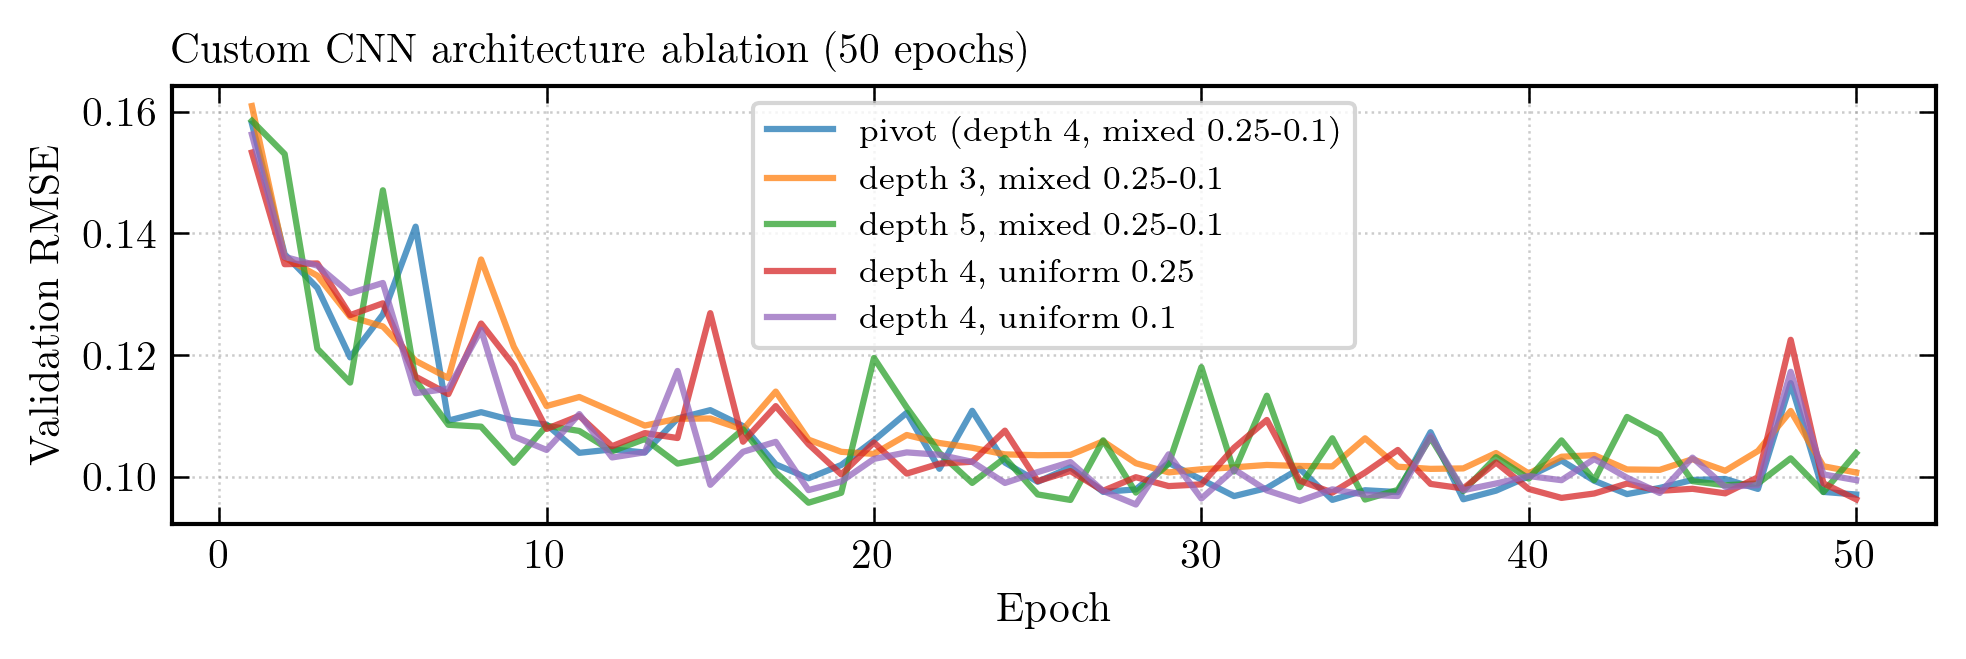

In [4]:
ax = plotters.plot_ablation_curves(
    ablation_names, ablation_val_losses,
    f"Custom CNN architecture ablation ({ABLATION_EPOCHS} epochs)",
)
plt.show()

**Sweep read-out.**

Each axis (depth and dropout) is a 3-point line through the pivot. Pick the lowest-RMSE variant on each axis — if both axes prefer the pivot, the pivot wins by transitivity; if either axis prefers a non-pivot, that variant becomes the candidate for the long run.

### The depth trade-off: resolution vs. abstraction

Increasing depth in this factory has two coupled effects, *by design*: each `MaxPool2d(2, 2)` halves spatial size, and we double the channel count per block to keep per-block FLOPs roughly constant (a conv of spatial $s$ and channels $c$ costs $\propto s^2 c^2$, so as $s \to s/2$ and $c \to 2c$ the product is preserved).

| Depth | Final feature map | Flatten dim | What you gain | What you lose |
|---:|---|---:|---|---|
| 3 | $12^2 \times 128$ | **18 432** | Higher spatial resolution → better at fine features (spiral-arm pitch, small bars). | Huge FC head — most of the model's parameters live in $18432 \to 256$. Overfitting risk goes way up. |
| 4 | $6^2 \times 256$ | **9 216** | Balanced — the textbook configuration. | — |
| 5 | $3^2 \times 512$ | **4 608** | More abstract features (deeper receptive field), smaller FC head. | At $3 \times 3$ there is almost no spatial structure left for the classifier. |

So as depth grows you are trading **spatial resolution** for **channel depth + abstraction**, and the FC bottleneck swings dramatically the other way.

### The dropout axis: why tapered vs uniform

The three depth-4 variants on the dropout axis sit in a different parameter space than the depth axis. Their FC head looks like:

| Variant | FC1 dropout | FC2 dropout | Idea |
|---|---:|---:|---|
| uniform 0.1 | 0.1 | 0.1 | Lighter regularisation everywhere |
| **mixed (pivot)** | **0.25** | **0.1** | Heavier where parameters are (FC1 holds ~85 % of the model's params), lighter where they aren't |
| uniform 0.25 | 0.25 | 0.25 | Heavier regularisation everywhere |

The mixed pivot beats *both* uniforms only if **tapering** is a better idea than either flat value at the same average — i.e. dropout concentrated on the overparameterised FC1 is more useful than the same total amount spread evenly across both FCs. If uniform 0.1 wins, FC1 doesn't actually need heavier dropout; if uniform 0.25 wins, the extra dropout on FC2 isn't slowing things down enough to matter.

### Reading the loss-curve plot

Overlaying the five 50-epoch validation curves rather than just the best-epoch bars exposes more information than a bar chart:

- **Convergence rate** — variants that converge slower (e.g. depth 5, where the optimiser has to push gradients through more layers) start higher and catch up later; their best-epoch number alone hides that.
- **Late-epoch behaviour** — if a curve is still trending down at epoch 50 it likely has more headroom under a longer schedule; if it has plateaued, the 50-epoch budget is enough to read its asymptote.
- **Overlap within axis** — if curves on the same axis (depth or dropout) sit on top of each other for the whole 50 epochs, the variable is genuinely insensitive and we can pick the cheaper / more interpretable end.

What to look for:

- **Depth axis ($\{3, 4, 5\}$ at fixed mixed dropout)**: depth 3 typically sits *above* the other two for the whole run because its FC head has to absorb a much larger flatten dim. Depth 5 may converge slower early but match or beat depth 4 by epoch 50.
- **Dropout axis ($\{[0.1,0.1],\ [0.25,0.1],\ [0.25,0.25]\}$ at depth 4)**: if all three curves are essentially indistinguishable, dropout level doesn't matter much at this scale; if the mixed pivot dips below both uniforms in the late epochs, tapering is doing genuine work.

### Choice

The loss-curve plot above shows that validation RMSE is **very similar across the depth axis** at 50 epochs — depths 3, 4, and 5 cluster within run-to-run noise of each other for most of the run. Given this near-tie, we lock in **depth 4** as the resolution-vs-abstraction balance point and the most defensible textbook configuration. The dropout axis then tells us whether the mixed $[0.25, 0.1]$ is empirically justified or if a uniform value works just as well — and the chosen variant goes into the 100-epoch run in `04b-custom-cnn.ipynb` for validation under a realistic training budget.

The trained weights for every variant are saved in `artifacts/ablation_*.pt` and the full per-epoch curves in `artifacts/ablation_*.npz`, so any per-variant downstream analysis (loss-curve comparison, per-label RMSE on the validation set, etc.) can be added later without retraining.